<a href="https://colab.research.google.com/github/Nvmdi/Machine-Learning-Task-/blob/main/Prediksi_Konsumsi_Bahan_Bakar_Kendaraan_Berdasarkan_Spesifikasi_Teknis_Menggunakan_Metode_Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Data understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
df = pd.read_csv('Konsumsi_bahan_bakar_2015-2024.csv', encoding='utf-8-sig')

print('=' * 60)
print('              INFORMASI DATASET')
print('=' * 60)
print(f'Jumlah baris    : {df.shape[0]}')
print(f'Jumlah kolom    : {df.shape[1]}')
print(f'Rentang tahun   : {df["Tahun Model"].min()} - {df["Tahun Model"].max()}')
print(f'Jumlah merek    : {df["Merek"].nunique()}')
print()
df.head(10)

              INFORMASI DATASET
Jumlah baris    : 10060
Jumlah kolom    : 15
Rentang tahun   : 2015 - 2024
Jumlah merek    : 42



,Tahun Model,Merek,Model,Kelas Kendaraan,Kapasitas Mesin (L),Jumlah Silinder,Transmisi,Jenis Bahan Bakar,Konsumsi BBM Dalam Kota (L/100 km),Konsumsi BBM Jalan Tol/Luar Kota (L/100 km),Konsumsi BBM Gabungan (L/100 km),Konsumsi BBM Gabungan (mpg),Emisi CO2 (g/km),Rating CO2,Rating Polusi
0,2015,Acura,ILX,Compact,2.0,4,AS5,Z,9.7,6.7,8.3,34,191,NaN,NaN
1,2015,Acura,ILX,Compact,2.4,4,M6,Z,10.8,7.4,9.3,30,214,NaN,NaN
2,2015,Acura,ILX Hybrid,Compact,1.5,4,AV7,Z,6.0,6.1,6.1,46,140,NaN,NaN
3,2015,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,NaN,NaN
4,2015,Acura,RDX AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,NaN,NaN
5,2015,Acura,RLX,Mid-size,3.5,6,AS6,Z,11.9,7.7,1.0,28,230,NaN,NaN
6,2015,Acura,RLX Hybrid,Mid-size,3.5,6,AM7,Z,8.0,7.5,7.7,37,177,NaN,NaN
7,2015,Acura,TLX,Compact,2.4,4,AM8,Z,9.6,6.6,8.3,34,191,NaN,NaN
8,2015,Acura,TLX,Compact,3.5,6,AS9,Z,11.2,6.9,9.2,31,212,NaN,NaN
9,2015,Acura,TLX SH-AWD,Compact,3.5,6,AS9,Z,11.2,7.5,9.6,29,221,NaN,NaN


In [ ]:
# Deskripsi variabel / fitur
feature_desc = pd.DataFrame({
    'Kolom'       : df.columns,
    'Tipe Data'   : df.dtypes.values,
    'Jumlah Unik' : [df[col].nunique() for col in df.columns],
    'Deskripsi'   : [
        'Tahun model kendaraan',
        'Merek kendaraan',
        'Model kendaraan',
        'Kategori kendaraan (SUV, Compact, dll.)',
        'Ukuran mesin dalam liter',
        'Jumlah silinder mesin',
        'Kode transmisi kendaraan',
        'Jenis bahan bakar (Z=Premium, X=Mid-grade, D=Diesel, E=Ethanol, N=Gas)',
        'Konsumsi BBM dalam kota (L per 100 km)',
        'Konsumsi BBM jalan tol (L per 100 km)',
        'Konsumsi BBM gabungan (L per 100 km) - TARGET',
        'Konsumsi BBM gabungan dalam mpg',
        'Emisi CO2 dalam gram per km',
        'Rating emisi CO2',
        'Rating polusi udara'
    ]
})
print('Deskripsi Variabel Dataset:')
print(feature_desc.to_string(index=False))

Deskripsi Variabel Dataset:
                                      Kolom Tipe Data  Jumlah Unik                                                              Deskripsi
                                Tahun Model     int64           10                                                  Tahun model kendaraan
                                      Merek    object           42                                                        Merek kendaraan
                                      Model    object         2081                                                        Model kendaraan
                            Kelas Kendaraan    object           15                                Kategori kendaraan (SUV, Compact, dll.)
                        Kapasitas Mesin (L)   float64           50                                               Ukuran mesin dalam liter
                            Jumlah Silinder     int64            8                                                  Jumlah silinder mesin
      

In [ ]:
# Statistik deskriptif
print('Statistik Deskriptif Variabel Numerik:')
df.describe()

Statistik Deskriptif Variabel Numerik:


,Tahun Model,Kapasitas Mesin (L),Jumlah Silinder,Konsumsi BBM Dalam Kota (L/100 km),Konsumsi BBM Jalan Tol/Luar Kota (L/100 km),Konsumsi BBM Gabungan (L/100 km),Konsumsi BBM Gabungan (mpg),Emisi CO2 (g/km),Rating CO2,Rating Polusi
count,10060.000000,10060.000000,10060.00000,10060.000000,10060.000000,10060.000000,10060.000000,10060.000000,8932.000000,7826.000000
mean,2019.242048,3.147316,5.61839,11.381004,8.754652,10.181123,27.436282,253.710338,4.617443,4.816509
std,2.834109,1.343258,1.87591,4.542195,2.575992,3.657919,7.316270,60.475197,1.574763,1.783793
min,2015.000000,1.000000,3.00000,1.000000,1.000000,1.000000,11.000000,94.000000,1.000000,1.000000
25%,2017.000000,2.000000,4.00000,9.300000,7.400000,8.400000,22.000000,210.000000,4.000000,3.000000
50%,2019.000000,3.000000,6.00000,11.600000,8.700000,10.300000,26.000000,250.000000,5.000000,5.000000
75%,2022.000000,3.700000,6.00000,14.100000,10.200000,12.300000,31.000000,292.000000,5.000000,6.000000
max,2024.000000,9.000000,16.00000,30.700000,20.900000,26.100000,71.000000,608.000000,10.000000,8.000000


In [ ]:
# Distribusi variabel kategorikal
cat_cols = ['Kelas Kendaraan', 'Jenis Bahan Bakar']
for col in cat_cols:
    print(f'\n{col} ({df[col].nunique()} nilai unik):')
    print(df[col].value_counts().to_string())


Kelas Kendaraan (15 nilai unik):
Kelas Kendaraan
Sport utility vehicle: Small       1868
Mid-size                           1393
Sport utility vehicle: Standard    1231
Compact                            1135
Pickup truck: Standard              878
Subcompact                          850
Full-size                           779
Two-seater                          639
Minicompact                         460
Station wagon: Small                282
Pickup truck: Small                 220
Special purpose vehicle             103
Minivan                              95
Station wagon: Mid-size              82
Van: Passenger                       45

Jenis Bahan Bakar (5 nilai unik):
Jenis Bahan Bakar
X    4756
Z    4739
E     328
D     236
N       1


2. Data preprocessing

In [ ]:
# 2.1 Cek Missing Values
print('Missing Values per Kolom:')
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_info = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_info)
print(f'\nTotal missing values: {missing.sum()}')

Missing Values per Kolom:
                                             Jumlah Missing  Persentase (%)
Tahun Model                                               0            0.00
Merek                                                     0            0.00
Model                                                     0            0.00
Kelas Kendaraan                                           0            0.00
Kapasitas Mesin (L)                                       0            0.00
Jumlah Silinder                                           0            0.00
Transmisi                                                 0            0.00
Jenis Bahan Bakar                                         0            0.00
Konsumsi BBM Dalam Kota (L/100 km)                        0            0.00
Konsumsi BBM Jalan Tol/Luar Kota (L/100 km)               0            0.00
Konsumsi BBM Gabungan (L/100 km)                          0            0.00
Konsumsi BBM Gabungan (mpg)                               0   

In [ ]:
# 2.2 Cek dan Hapus Data Duplikat
print(f'Jumlah data duplikat  : {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Jumlah data setelah hapus duplikat: {df.shape[0]}')

Jumlah data duplikat  : 0
Jumlah data setelah hapus duplikat: 10060


In [ ]:
# 2.3 Feature Engineering
# Membuat fitur baru: CC per Silinder (rasio kapasitas mesin terhadap jumlah silinder)
df['CC per Silinder'] = df['Kapasitas Mesin (L)'] / df['Jumlah Silinder']
print('Fitur baru CC per Silinder berhasil dibuat.')
print(df[['Kapasitas Mesin (L)', 'Jumlah Silinder', 'CC per Silinder']].head())

Fitur baru CC per Silinder berhasil dibuat.
   Kapasitas Mesin (L)  Jumlah Silinder  CC per Silinder
0                  2.0                4         0.500000
1                  2.4                4         0.600000
2                  1.5                4         0.375000
3                  3.5                6         0.583333
4                  3.5                6         0.583333


In [ ]:
# 2.4 Seleksi Fitur (Spesifikasi Teknis)
features_num = ['Tahun Model', 'Kapasitas Mesin (L)', 'Jumlah Silinder', 'CC per Silinder']
features_cat = ['Kelas Kendaraan', 'Jenis Bahan Bakar', 'Transmisi']
target       = 'Konsumsi BBM Gabungan (L/100 km)'

all_features = features_num + features_cat
df_model     = df[all_features + [target]].dropna().copy()

print(f'Data setelah seleksi fitur dan hapus NaN: {df_model.shape[0]} baris')
print(f'\nFitur Numerik  : {features_num}')
print(f'Fitur Kategori : {features_cat}')
print(f'Target         : {target}')

Data setelah seleksi fitur dan hapus NaN: 10060 baris

Fitur Numerik  : ['Tahun Model', 'Kapasitas Mesin (L)', 'Jumlah Silinder', 'CC per Silinder']
Fitur Kategori : ['Kelas Kendaraan', 'Jenis Bahan Bakar', 'Transmisi']
Target         : Konsumsi BBM Gabungan (L/100 km)


In [ ]:
# 2.5 Pengelompokan Kolom Transmisi
def group_transmisi(t):
    t = str(t).upper().strip()
    if t.startswith('A') or 'AV' in t:
        return 'Otomatis'
    elif t.startswith('M'):
        return 'Manual'
    else:
        return 'Lainnya'

df['Transmisi'] = df['Transmisi'].apply(group_transmisi)

print('Distribusi Transmisi setelah pengelompokan:')
print(df['Transmisi'].value_counts().to_string())

Distribusi Transmisi setelah pengelompokan:
Transmisi
Otomatis    8728
Manual      1332


In [ ]:
# 2.6 Deteksi dan Penanganan Outlier (Metode IQR)
X_raw = df_model[all_features]
y_raw = df_model[target]

Q1  = y_raw.quantile(0.25)
Q3  = y_raw.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = y_raw[(y_raw < lower_bound) | (y_raw > upper_bound)]
print(f'Q1              : {Q1}')
print(f'Q3              : {Q3}')
print(f'IQR             : {IQR}')
print(f'Batas bawah     : {lower_bound:.2f}')
print(f'Batas atas      : {upper_bound:.2f}')
print(f'Jumlah outlier  : {len(outliers)}')

mask    = (y_raw >= lower_bound) & (y_raw <= upper_bound)
X_clean = X_raw[mask].copy()
y_clean = y_raw[mask].copy()
print(f'\nData sebelum hapus outlier : {len(y_raw)}')
print(f'Data setelah hapus outlier : {len(y_clean)}')

Q1              : 8.4
Q3              : 12.3
IQR             : 3.9000000000000004
Batas bawah     : 2.55
Batas atas      : 18.15
Jumlah outlier  : 842

Data sebelum hapus outlier : 10060
Data setelah hapus outlier : 9218


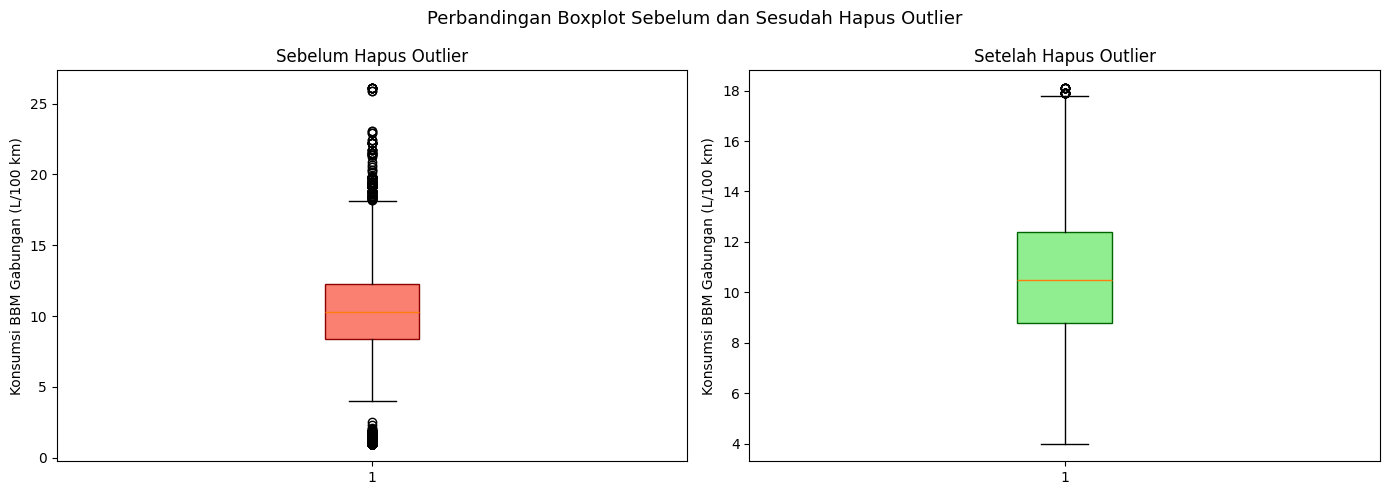

In [ ]:
# Visualisasi sebelum dan sesudah hapus outlier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(y_raw, vert=True, patch_artist=True,
                boxprops=dict(facecolor='salmon', color='darkred'))
axes[0].set_title('Sebelum Hapus Outlier', fontsize=12)
axes[0].set_ylabel('Konsumsi BBM Gabungan (L/100 km)')

axes[1].boxplot(y_clean, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='darkgreen'))
axes[1].set_title('Setelah Hapus Outlier', fontsize=12)
axes[1].set_ylabel('Konsumsi BBM Gabungan (L/100 km)')

plt.suptitle('Perbandingan Boxplot Sebelum dan Sesudah Hapus Outlier', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 2.7 Encoding Kategorikal + Standarisasi Numerik
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_cat)
])

X_processed = preprocessor.fit_transform(X_clean)
y           = y_clean.values

ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(features_cat)
all_feature_names = features_num + list(ohe_feature_names)

print(f'Jumlah fitur setelah encoding : {X_processed.shape[1]}')
print(f'Shape X_processed             : {X_processed.shape}')
print(f'Shape y                       : {y.shape}')

Jumlah fitur setelah encoding : 51
Shape X_processed             : (9218, 51)
Shape y                       : (9218,)


3. Explalotary Data Analysis (EDA)

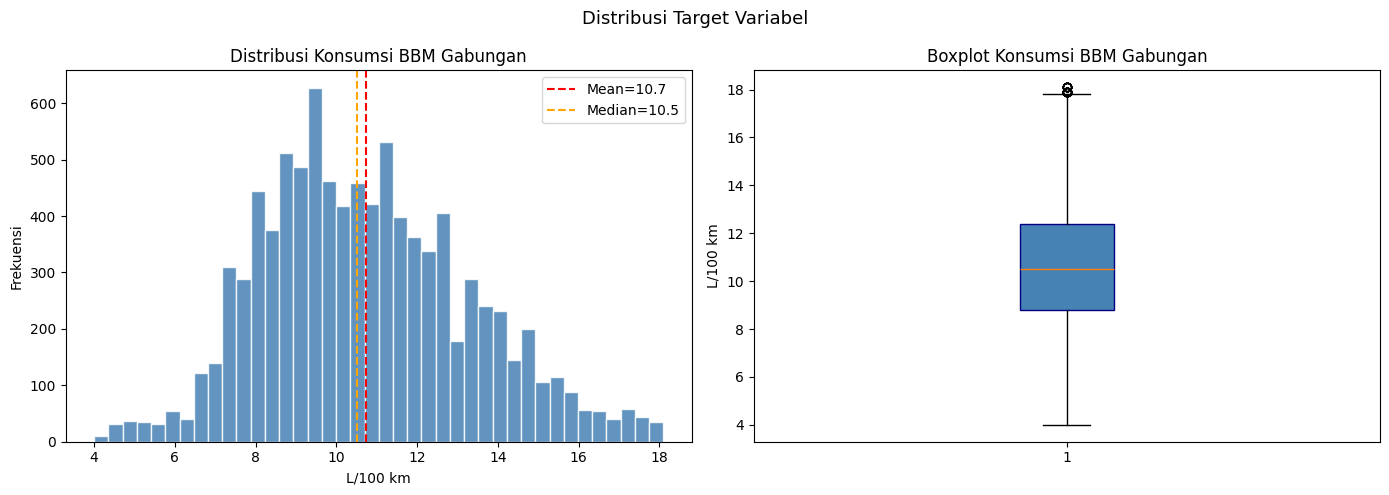

In [ ]:
# 3.1 Distribusi Target Variabel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_clean, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(y_clean.mean(),   color='red',    linestyle='--', label=f'Mean={y_clean.mean():.1f}')
axes[0].axvline(y_clean.median(), color='orange', linestyle='--', label=f'Median={y_clean.median():.1f}')
axes[0].set_title('Distribusi Konsumsi BBM Gabungan', fontsize=12)
axes[0].set_xlabel('L/100 km')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

axes[1].boxplot(y_clean, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot Konsumsi BBM Gabungan', fontsize=12)
axes[1].set_ylabel('L/100 km')

plt.suptitle('Distribusi Target Variabel', fontsize=13)
plt.tight_layout()
plt.show()

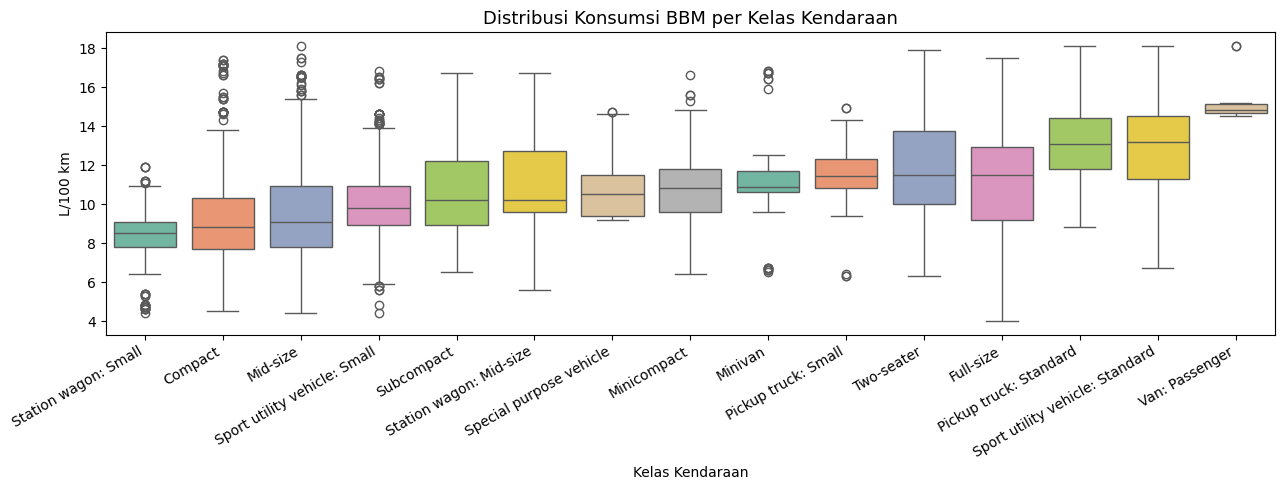

In [ ]:
# 3.2 Distribusi konsumsi BBM per kelas kendaraan
df_clean         = X_clean.copy()
df_clean[target] = y_clean.values

plt.figure(figsize=(13, 5))
order = df_clean.groupby('Kelas Kendaraan')[target].median().sort_values().index
sns.boxplot(data=df_clean, x='Kelas Kendaraan', y=target, order=order, palette='Set2')
plt.title('Distribusi Konsumsi BBM per Kelas Kendaraan', fontsize=13)
plt.xlabel('Kelas Kendaraan')
plt.ylabel('L/100 km')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

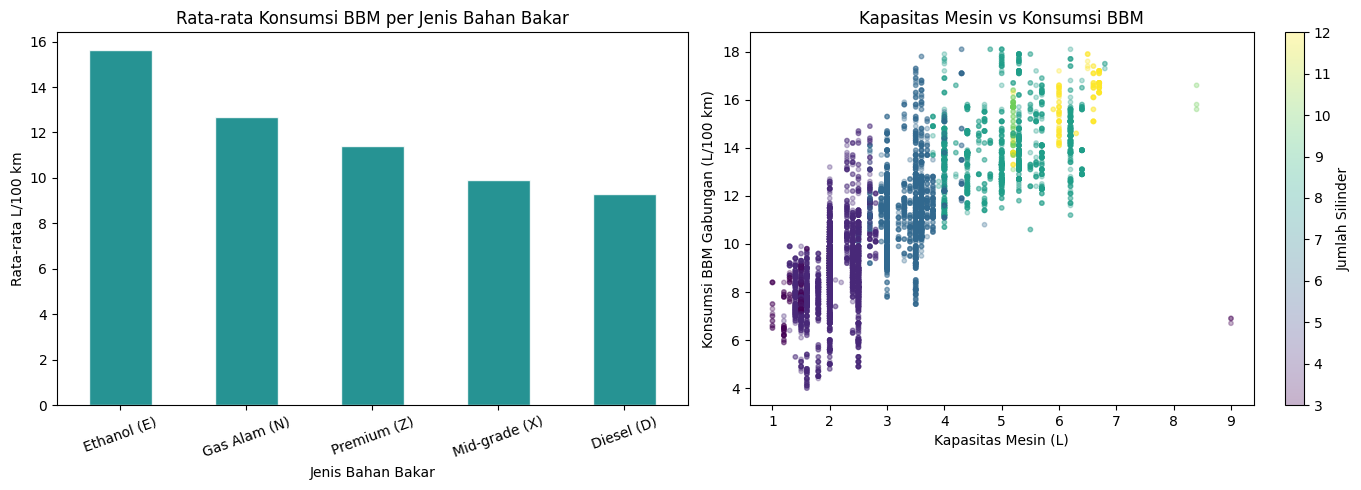

In [ ]:
# 3.3 Rata-rata konsumsi per jenis bahan bakar & scatter kapasitas mesin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_fuel = df_clean.groupby('Jenis Bahan Bakar')[target].mean().sort_values(ascending=False)
fuel_labels = {'Z': 'Premium (Z)', 'X': 'Mid-grade (X)', 'D': 'Diesel (D)',
               'E': 'Ethanol (E)', 'N': 'Gas Alam (N)'}
avg_fuel.index = [fuel_labels.get(i, i) for i in avg_fuel.index]
avg_fuel.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white', alpha=0.85)
axes[0].set_title('Rata-rata Konsumsi BBM per Jenis Bahan Bakar', fontsize=12)
axes[0].set_xlabel('Jenis Bahan Bakar')
axes[0].set_ylabel('Rata-rata L/100 km')
axes[0].tick_params(axis='x', rotation=20)

scatter = axes[1].scatter(df_clean['Kapasitas Mesin (L)'], df_clean[target],
                          alpha=0.3, s=10, c=df_clean['Jumlah Silinder'], cmap='viridis')
plt.colorbar(scatter, ax=axes[1], label='Jumlah Silinder')
axes[1].set_title('Kapasitas Mesin vs Konsumsi BBM', fontsize=12)
axes[1].set_xlabel('Kapasitas Mesin (L)')
axes[1].set_ylabel('Konsumsi BBM Gabungan (L/100 km)')

plt.tight_layout()
plt.show()

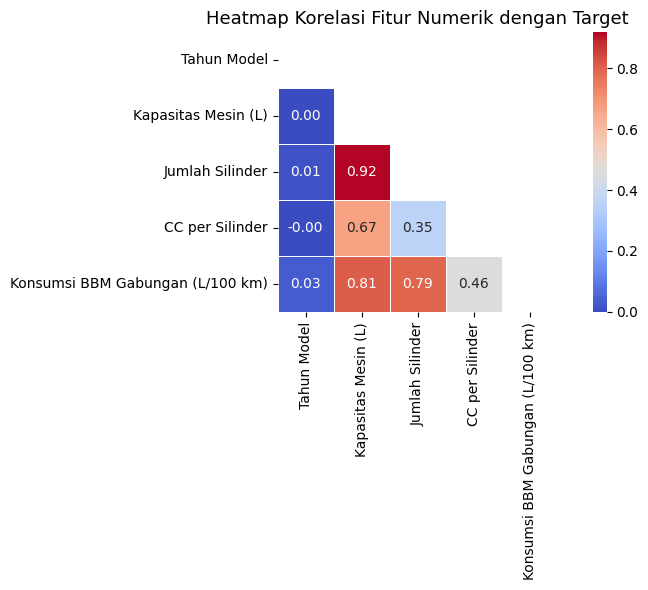

In [ ]:
# 3.4 Heatmap korelasi fitur numerik
num_cols = ['Tahun Model', 'Kapasitas Mesin (L)', 'Jumlah Silinder', 'CC per Silinder', target]
df_corr  = df_clean[num_cols]

plt.figure(figsize=(9, 6))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True, annot_kws={'size': 10})
plt.title('Heatmap Korelasi Fitur Numerik dengan Target', fontsize=13)
plt.tight_layout()
plt.show()

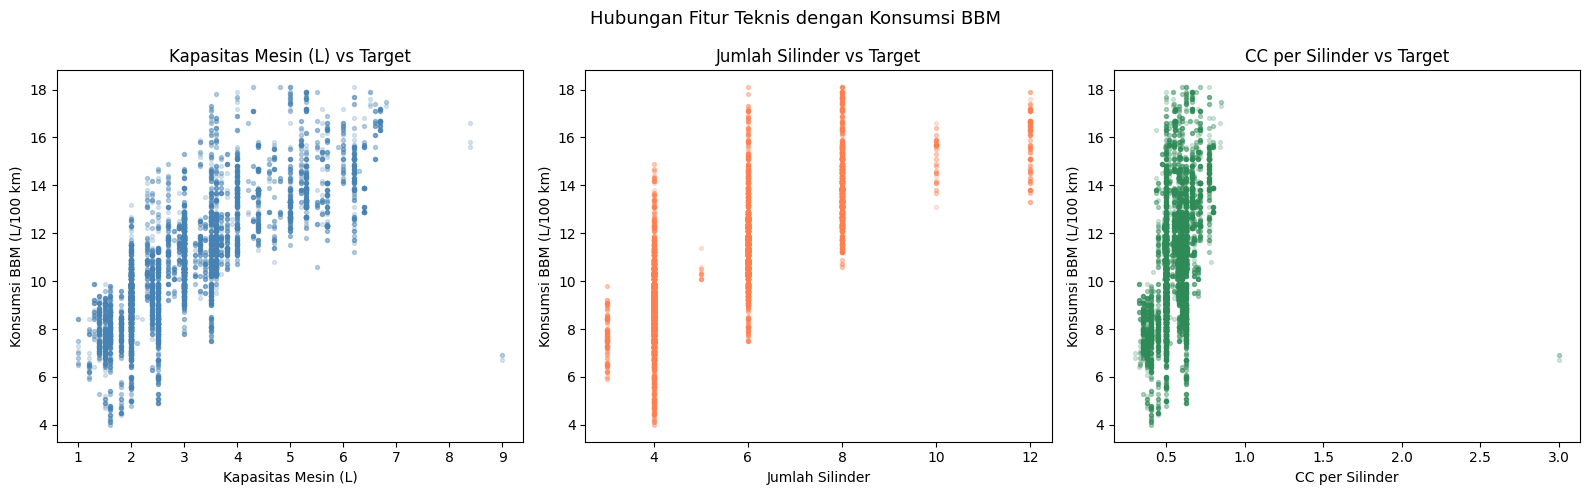

In [ ]:
# 3.5 Scatter plot fitur utama vs target
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
scatter_pairs = [
    ('Kapasitas Mesin (L)',  'steelblue'),
    ('Jumlah Silinder',      'coral'),
    ('CC per Silinder',      'seagreen'),
]
for ax, (col, color) in zip(axes, scatter_pairs):
    ax.scatter(df_clean[col], df_clean[target], alpha=0.2, s=8, color=color)
    ax.set_xlabel(col)
    ax.set_ylabel('Konsumsi BBM (L/100 km)')
    ax.set_title(f'{col} vs Target')
plt.suptitle('Hubungan Fitur Teknis dengan Konsumsi BBM', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
4. Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

splits_config = [
    {'name': '90/10', 'test_size': 0.10},
]

split_data = {}
print(f'Total data: {len(X_processed)}')
print()
print(f'{"Split":<10} {"Train":<10} {"Test":<10} {"Train %":<12} {"Test %"}')
print('-' * 52)
for s in splits_config:
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=s['test_size'], random_state=42
    )
    split_data[s['name']] = (X_train, X_test, y_train, y_test)
    train_pct = (1 - s['test_size']) * 100
    test_pct  = s['test_size'] * 100
    print(f"{s['name']:<10} {len(X_train):<10} {len(X_test):<10} {train_pct:<12.0f} {test_pct:.0f}")

Total data: 9218

Split      Train      Test       Train %      Test %
----------------------------------------------------
90/10      8296       922        90           10


5. Model building

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'y_pred': y_pred}

# Definisi model awal (sebelum tuning)
base_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree'    : DecisionTreeRegressor(random_state=42),
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42),
}

print('=== Hasil Model Sebelum Hyperparameter Tuning ===')
results_before = {}
for split_name, (X_train, X_test, y_train, y_test) in split_data.items():
    results_before[split_name] = {}
    print(f'\n  Split {split_name}:')
    for model_name, model in base_models.items():
        metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
        results_before[split_name][model_name] = metrics
        print(f'    {model_name:22s} | MAE={metrics["MAE"]:.4f} | RMSE={metrics["RMSE"]:.4f} | R2={metrics["R2"]*100:.2f}%')

=== Hasil Model Sebelum Hyperparameter Tuning ===

  Split 90/10:
    Linear Regression      | MAE=0.7832 | RMSE=1.0259 | R2=82.96%
    Decision Tree          | MAE=0.5138 | RMSE=0.7679 | R2=90.45%
    Random Forest          | MAE=0.5122 | RMSE=0.7375 | R2=91.19%


6. Hyperparameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

# Gunakan split 80/20 untuk tuning
split_name = list(split_data.keys())[0]
X_train_tune, X_test_tune, y_train_tune, y_test_tune = split_data[split_name]

print('=== Hyperparameter Tuning ===')

# 1. Linear Regression - tidak memerlukan tuning
lr_best = LinearRegression()
lr_best.fit(X_train_tune, y_train_tune)
print('\n1. Linear Regression: tidak memerlukan tuning (solusi analitik optimal)')

# 2. Decision Tree GridSearchCV
dt_param_grid = {
    'max_depth'        : [8, 10, 12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 3]
}
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid, cv=3, scoring='r2', n_jobs=-1
)
dt_grid.fit(X_train_tune, y_train_tune)
print(f'\n2. Decision Tree - Best Params: {dt_grid.best_params_}')
print(f'   Best CV R2: {dt_grid.best_score_*100:.2f}%')

# 3. Random Forest GridSearchCV
# Split name is already determined in the previous cell
# X_train_tune, X_test_tune, y_train_tune, y_test_tune = split_data[split_name]

rf_param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [15, 20, None],
    'min_samples_split': [2, 3]
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid, cv=3, scoring='r2', n_jobs=-1
)
rf_grid.fit(X_train_tune, y_train_tune)
print(f'3. Random Forest - Best Params: {rf_grid.best_params_}')
print(f'   Best CV R2: {rf_grid.best_score_*100:.2f}%')

=== Hyperparameter Tuning ===

1. Linear Regression: tidak memerlukan tuning (solusi analitik optimal)

2. Decision Tree - Best Params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}
   Best CV R2: 89.82%
3. Random Forest - Best Params: {'max_depth': 20, 'min_samples_split': 3, 'n_estimators': 200}
   Best CV R2: 91.88%


7. Model evaluation

In [ ]:
# Model setelah tuning
tuned_models = {
    'Linear Regression': lr_best,
    'Decision Tree'    : dt_grid.best_estimator_,
    'Random Forest'    : rf_grid.best_estimator_,
}

print('=== Hasil Model Setelah Hyperparameter Tuning ===')
results_after = {}
for split_name, (X_train, X_test, y_train, y_test) in split_data.items():
    results_after[split_name] = {}
    print(f'\n  Split {split_name}:')
    for model_name, model in tuned_models.items():
        metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
        results_after[split_name][model_name] = metrics
        print(f'    {model_name:22s} | MAE={metrics["MAE"]:.4f} | RMSE={metrics["RMSE"]:.4f} | R2={metrics["R2"]*100:.2f}%')

=== Hasil Model Setelah Hyperparameter Tuning ===

  Split 90/10:
    Linear Regression      | MAE=0.7832 | RMSE=1.0259 | R2=82.96%
    Decision Tree          | MAE=0.5656 | RMSE=0.8113 | R2=89.34%
    Random Forest          | MAE=0.5078 | RMSE=0.7287 | R2=91.40%


In [ ]:
# Tabel evaluasi lengkap per split
for split_name in split_data.keys():
    print(f'\n======= Evaluasi Model | Split {split_name} =======')
    rows = []
    for model_name, metrics in results_after[split_name].items():
        rows.append({
            'Model'   : model_name,
            'MAE'     : round(metrics['MAE'],  4),
            'MSE'     : round(metrics['MSE'],  4),
            'RMSE'    : round(metrics['RMSE'], 4),
            'R2 Score': round(metrics['R2'],   4),
            'R2 (%)'  : round(metrics['R2'] * 100, 2)
        })
    eval_df = pd.DataFrame(rows)
    print(eval_df.to_string(index=False))


======= Evaluasi Model | Split 90/10 =======
            Model    MAE    MSE   RMSE  R2 Score  R2 (%)
Linear Regression 0.7832 1.0525 1.0259    0.8296   82.96
    Decision Tree 0.5656 0.6583 0.8113    0.8934   89.34
    Random Forest 0.5078 0.5311 0.7287    0.9140   91.40


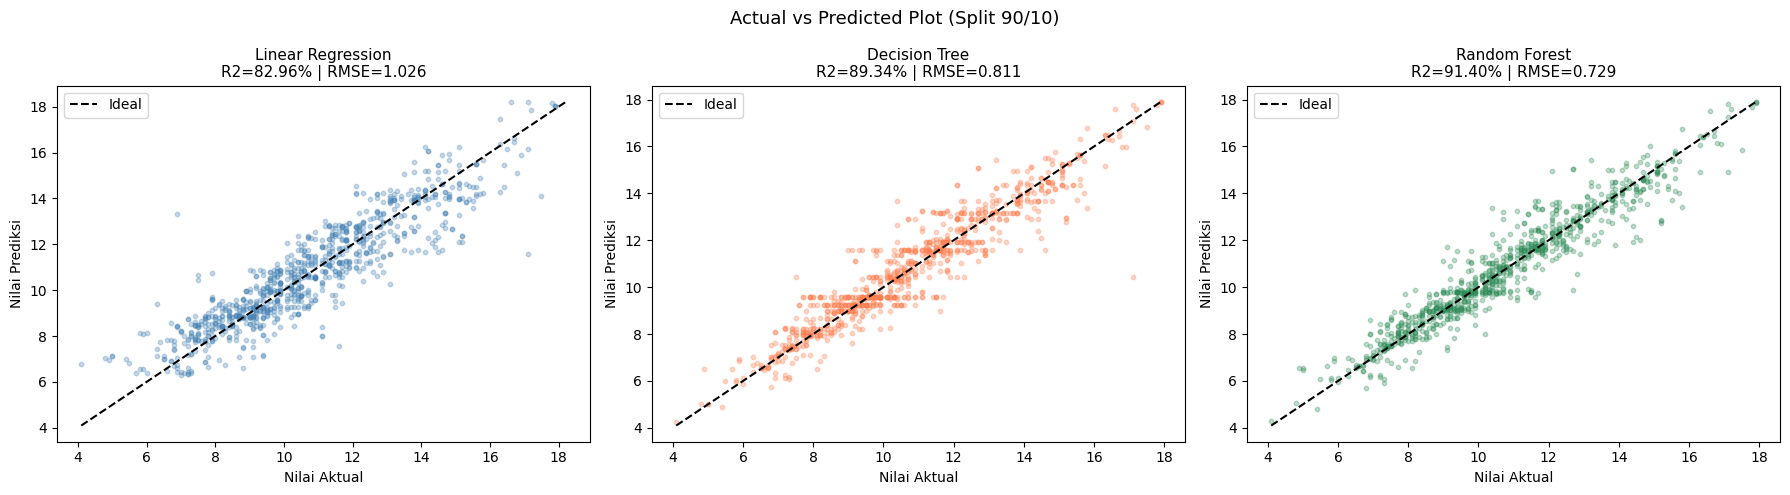

In [ ]:
# Actual vs Predicted Plot (Dynamic Split)
split_name = list(split_data.keys())[0]
X_train, X_test, y_train, y_test = split_data[split_name]
plot_colors = ['steelblue', 'coral', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, model), color in zip(axes, tuned_models.items(), plot_colors):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color=color)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Ideal')
    ax.set_xlabel('Nilai Aktual')
    ax.set_ylabel('Nilai Prediksi')
    ax.set_title(f'{model_name}\nR2={r2*100:.2f}% | RMSE={rmse:.3f}', fontsize=11)
    ax.legend()

plt.suptitle(f'Actual vs Predicted Plot (Split {split_name})', fontsize=13)
plt.tight_layout()
plt.show()

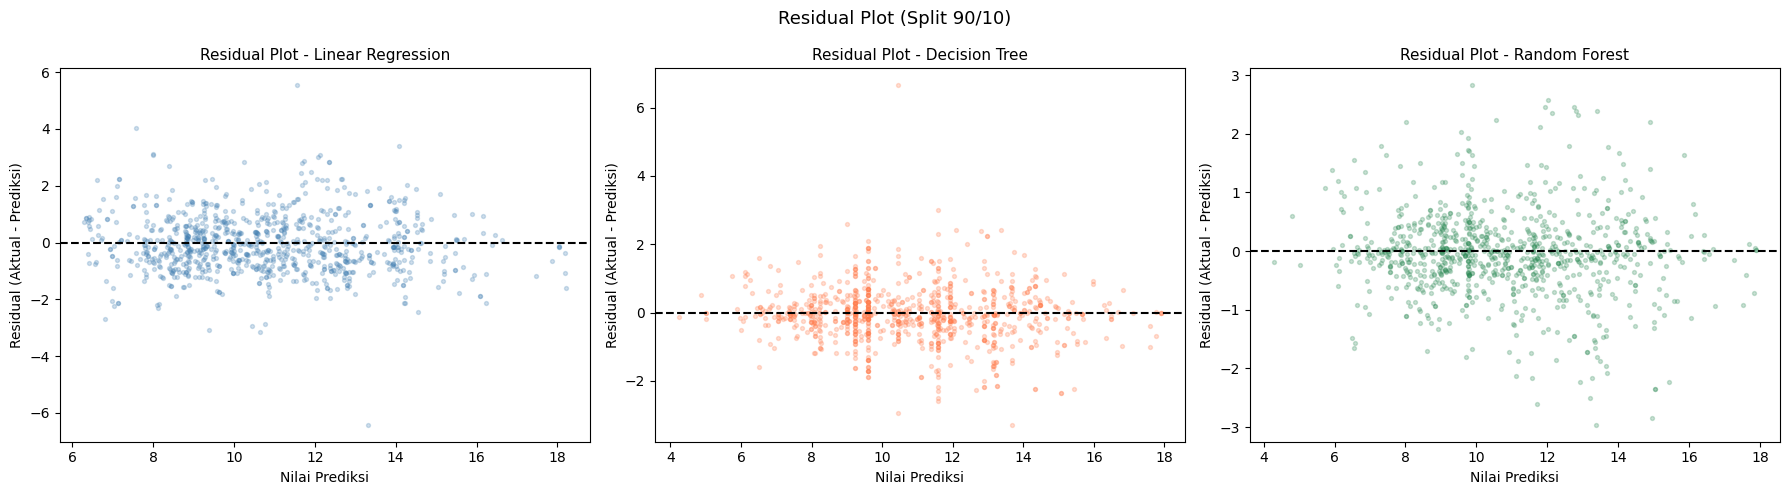

In [ ]:
# Residual Plot (Dynamic Split)
split_name = list(split_data.keys())[0]
X_train, X_test, y_train, y_test = split_data[split_name]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, model), color in zip(axes, tuned_models.items(), plot_colors):
    model.fit(X_train, y_train)
    y_pred    = model.predict(X_test)
    residuals = np.array(y_test) - y_pred

    ax.scatter(y_pred, residuals, alpha=0.25, s=8, color=color)
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
    ax.set_title(f'Residual Plot - {model_name}', fontsize=11)
    ax.set_xlabel('Nilai Prediksi')
    ax.set_ylabel('Residual (Aktual - Prediksi)')

plt.suptitle(f'Residual Plot (Split {split_name})', fontsize=13)
plt.tight_layout()
plt.show()

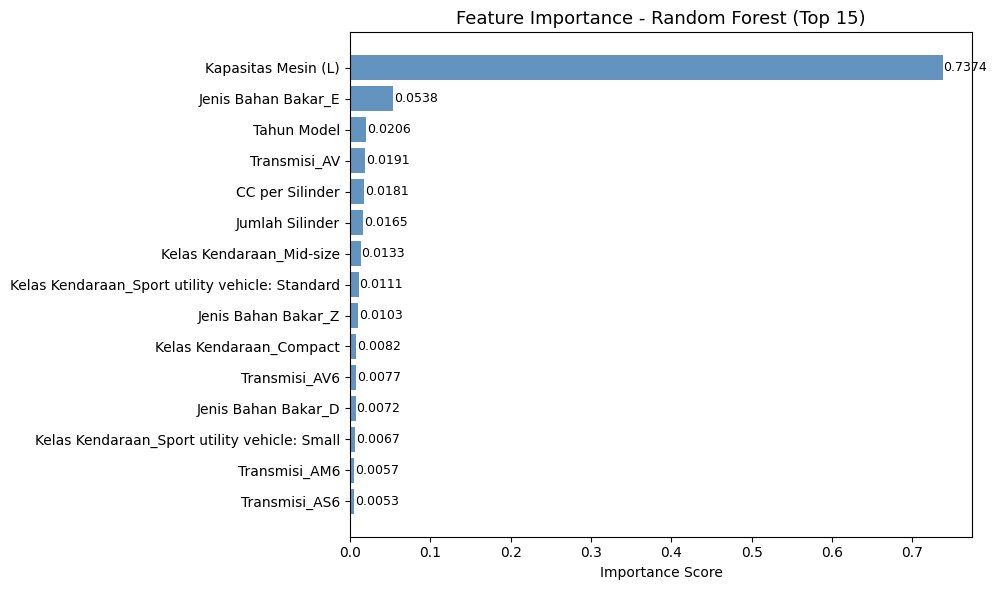


Top 5 Fitur Paling Berpengaruh:
Kapasitas Mesin (L)    0.737408
Jenis Bahan Bakar_E    0.053769
Tahun Model            0.020555
Transmisi_AV           0.019146
CC per Silinder        0.018122


In [ ]:
# Feature Importance - Random Forest
split_name = list(split_data.keys())[0]
X_train, X_test, y_train, y_test = split_data[split_name]

rf_final = tuned_models['Random Forest']
rf_final.fit(X_train, y_train)

importances = pd.Series(
    rf_final.feature_importances_,
    index=all_feature_names
).sort_values(ascending=True)

top_importances = importances.tail(15)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_importances.index, top_importances.values, color='steelblue', alpha=0.85)
for bar, val in zip(bars, top_importances.values):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.title('Feature Importance - Random Forest (Top 15)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 Fitur Paling Berpengaruh:')
print(importances.tail(5).sort_values(ascending=False).to_string())

In [ ]:
# Perbandingan Sebelum vs Sesudah Tuning (Dynamic Split)
split_name = list(split_data.keys())[0]
print(f'=== Perbandingan Sebelum vs Sesudah Tuning (Split {split_name}) ===')
print(f'{"Model":<22} | {"Sebelum":>10} | {"Sesudah":>10} | {"Delta":>8}')
print('-' * 60)
for model_name in tuned_models.keys():
    r2_before = results_before[split_name][model_name]['R2']
    r2_after  = results_after[split_name][model_name]['R2']
    delta     = r2_after - r2_before
    print(f'{model_name:<22} | {r2_before*100:>9.2f}% | {r2_after*100:>9.2f}% | {delta*100:>+7.2f}%')

=== Perbandingan Sebelum vs Sesudah Tuning (Split 90/10) ===
Model                  |    Sebelum |    Sesudah |    Delta
------------------------------------------------------------
Linear Regression      |     82.96% |     82.96% |   +0.00%
Decision Tree          |     90.45% |     89.34% |   -1.11%
Random Forest          |     91.19% |     91.40% |   +0.21%


8. Model comparison

In [ ]:
# Tabel perbandingan semua model dan semua split
comp_rows = []
for split_name, model_results in results_after.items():
    for model_name, metrics in model_results.items():
        comp_rows.append({
            'Split'   : split_name,
            'Model'   : model_name,
            'MAE'     : round(metrics['MAE'],  4),
            'MSE'     : round(metrics['MSE'],  4),
            'RMSE'    : round(metrics['RMSE'], 4),
            'R2 Score': round(metrics['R2'],   4),
            'R2 (%)'  : round(metrics['R2'] * 100, 2)
        })

comp_df = pd.DataFrame(comp_rows)
print('=== Tabel Perbandingan Lengkap Semua Model dan Split ===')
print(comp_df.to_string(index=False))

=== Tabel Perbandingan Lengkap Semua Model dan Split ===
Split             Model    MAE    MSE   RMSE  R2 Score  R2 (%)
90/10 Linear Regression 0.7832 1.0525 1.0259    0.8296   82.96
90/10     Decision Tree 0.5656 0.6583 0.8113    0.8934   89.34
90/10     Random Forest 0.5078 0.5311 0.7287    0.9140   91.40


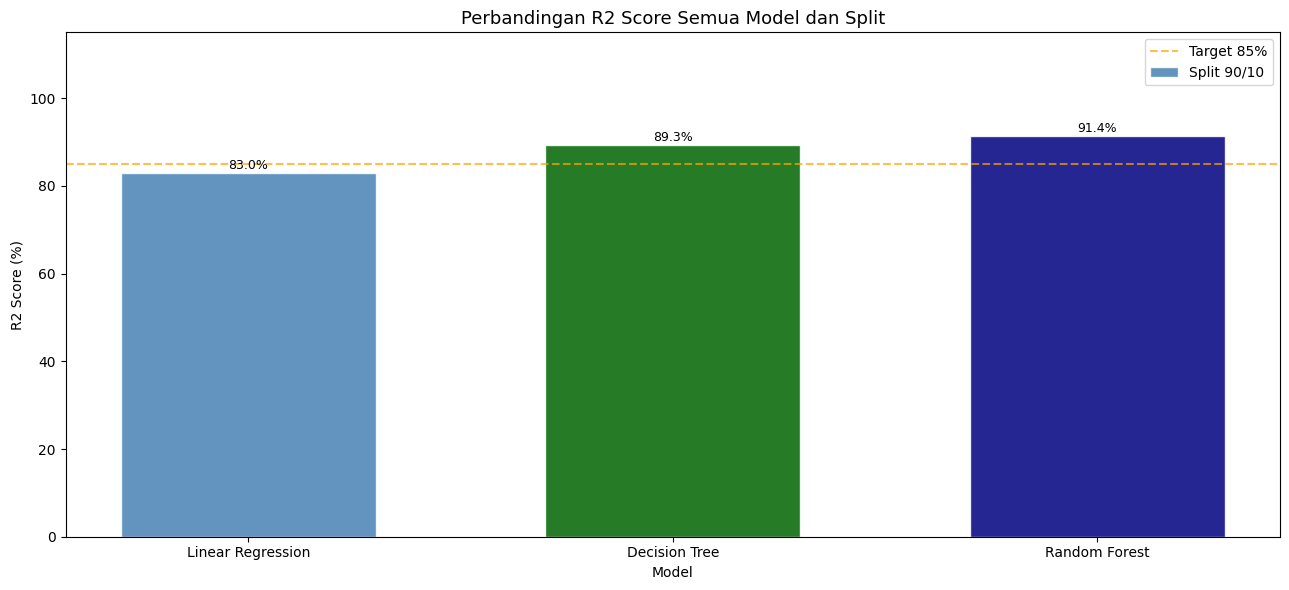

In [ ]:
model_names = list(tuned_models.keys())
split_names = list(split_data.keys())
x           = np.arange(len(model_names))
width       = 0.6  # Increased width for closer bars

# Define a color palette for the models
model_colors = ['steelblue', 'darkgreen', 'navy'] # Changed colors to specific shades

fig, ax = plt.subplots(figsize=(13, 6))
for i, split_name in enumerate(split_names):
    r2_vals = [results_after[split_name][m]['R2'] * 100 for m in model_names]
    bars = ax.bar(x + i * width, r2_vals, width, label=f'Split {split_name}',
                  color=[model_colors[j] for j in range(len(model_names))], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model')
ax.set_ylabel('R2 Score (%)')
ax.set_title('Perbandingan R2 Score Semua Model dan Split', fontsize=13)
ax.set_xticks(x)  # Centered ticks
ax.set_xticklabels(model_names)
ax.set_ylim(0, 115)
ax.axhline(85, color='orange', linestyle='--', alpha=0.7, label='Target 85%')
ax.legend()
plt.tight_layout()
plt.show()

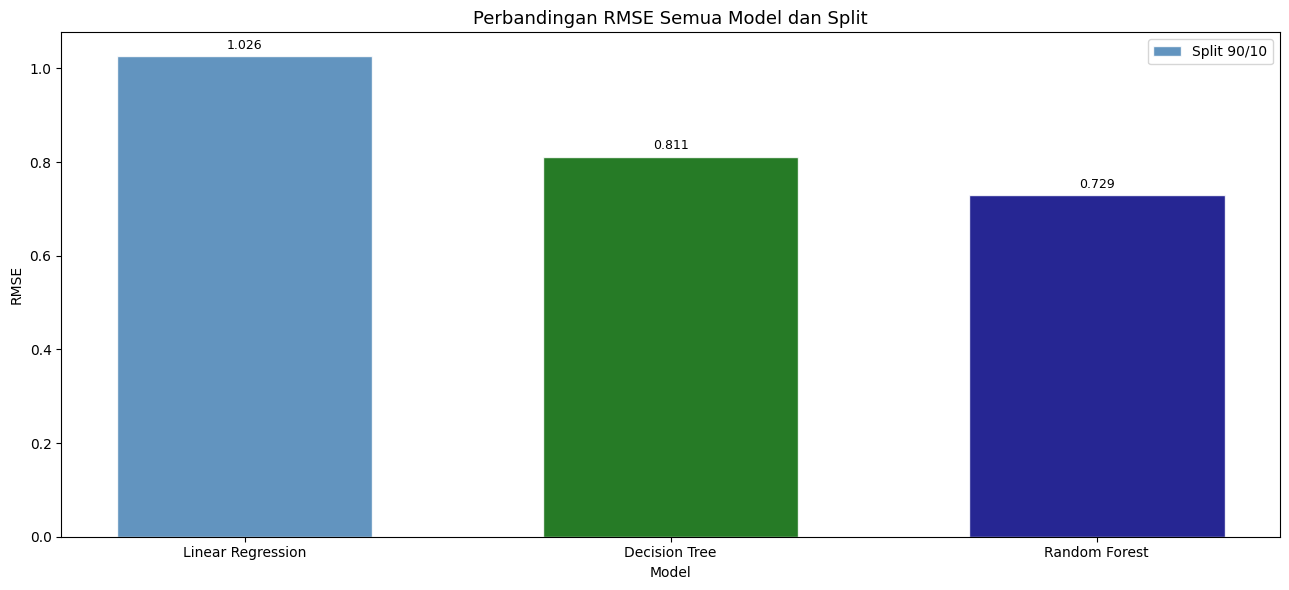

In [ ]:
# Bar chart perbandingan RMSE
model_names = list(tuned_models.keys())
split_names = list(split_data.keys())
x           = np.arange(len(model_names))
width       = 0.6  # Increased width for closer bars

# Define a color palette for the models
model_colors = ['steelblue', 'darkgreen', 'navy'] # Changed colors to specific shades

fig, ax = plt.subplots(figsize=(13, 6))
for i, split_name in enumerate(split_names):
    rmse_vals = [results_after[split_name][m]['RMSE'] for m in model_names]
    bars = ax.bar(x + i * width, rmse_vals, width, label=f'Split {split_name}',
                  color=[model_colors[j] for j in range(len(model_names))], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, rmse_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model')
ax.set_ylabel('RMSE')
ax.set_title('Perbandingan RMSE Semua Model dan Split', fontsize=13)
ax.set_xticks(x)  # Centered ticks
ax.set_xticklabels(model_names)
ax.legend()
plt.tight_layout()
plt.show()

9. Inferensi model

In [ ]:
# ============================================================
# 5. INFERENSI - Prediksi Konsumsi BBM Kendaraan Baru
# ============================================================

# ── BAGIAN YANG BISA KAMU UBAH ──────────────────────────────
input_kendaraan = {
    'Tahun Model'        : 2023,          # Tahun model kendaraan (2015-2024)
    'Kapasitas Mesin (L)': 2.0,           # Kapasitas mesin dalam liter
    'Jumlah Silinder'    : 4,             # Jumlah silinder (3,4,6,8,10,12,16)
    'Kelas Kendaraan'    : 'Compact',     # Lihat daftar kelas di bawah
    'Jenis Bahan Bakar'  : 'Z',           # Z=Premium, X=Mid-grade, D=Diesel, E=Ethanol, N=Gas
    'Transmisi'          : 'Otomatis',    # Otomatis / Manual / Lainnya
}
# ────────────────────────────────────────────────────────────

# Referensi pilihan Kelas Kendaraan:
# 'Compact', 'Mid-size', 'Full-size', 'Subcompact', 'Minicompact',
# 'Two-seater', 'Sport utility vehicle: Small', 'Sport utility vehicle: Standard',
# 'Station wagon: Small', 'Station wagon: Mid-size',
# 'Pickup truck: Small', 'Pickup truck: Standard',
# 'Van: Passenger', 'Minivan', 'Special purpose vehicle'

print('=' * 60)
print('         INFERENSI PREDIKSI KONSUMSI BBM')
print('=' * 60)
print('\nSpesifikasi Kendaraan Input:')
for k, v in input_kendaraan.items():
    print(f'  {k:<25} : {v}')

# Hitung CC per Silinder (fitur turunan)
cc_per_silinder = input_kendaraan['Kapasitas Mesin (L)'] / input_kendaraan['Jumlah Silinder']

# Susun DataFrame input sesuai urutan fitur saat training
df_input = pd.DataFrame([{
    'Tahun Model'        : input_kendaraan['Tahun Model'],
    'Kapasitas Mesin (L)': input_kendaraan['Kapasitas Mesin (L)'],
    'Jumlah Silinder'    : input_kendaraan['Jumlah Silinder'],
    'CC per Silinder'    : cc_per_silinder,
    'Kelas Kendaraan'    : input_kendaraan['Kelas Kendaraan'],
    'Jenis Bahan Bakar'  : input_kendaraan['Jenis Bahan Bakar'],
    'Transmisi'          : input_kendaraan['Transmisi'],
}])

print(f'  {"CC per Silinder":<25} : {cc_per_silinder:.4f} (dihitung otomatis)')

# Transformasi menggunakan preprocessor yang sudah di-fit
X_input = preprocessor.transform(df_input)

# Prediksi dengan semua model yang sudah di-tuning
print('\n' + '=' * 60)
print('  HASIL PREDIKSI SEMUA MODEL')
print('=' * 60)
print(f'  {"Model":<22} | {"Prediksi (L/100 km)":>20} | {"Estimasi (km/L)":>15}')
print(f'  {"-"*22}-+-{"-"*20}-+-{"-"*15}')

prediksi_rf = None
for model_name, model in tuned_models.items():
    pred = model.predict(X_input)[0]
    kml  = 100 / pred
    print(f'  {model_name:<22} | {pred:>18.2f}   | {kml:>13.2f}  ')
    if model_name == 'Random Forest':
        prediksi_rf = pred

# Gunakan Random Forest sebagai prediksi utama (model terbaik)
pred_utama = prediksi_rf
kml_utama  = 100 / pred_utama

print()
print('=' * 60)
print('  PREDIKSI UTAMA  →  Random Forest (Model Terbaik)')
print('=' * 60)
print(f'  Konsumsi BBM Gabungan : {pred_utama:.2f} L/100 km')
print(f'  Setara dengan         : {kml_utama:.2f} km/L')

# Interpretasi kategori konsumsi
if pred_utama < 7.0:
    kategori = 'Sangat Irit'
    ket      = '(kelas hybrid/listrik ringan)'
elif pred_utama < 9.0:
    kategori = 'Irit'
    ket      = '(kelas city car / sedan kecil)'
elif pred_utama < 12.0:
    kategori = 'Normal'
    ket      = '(kelas sedan / SUV kecil)'
elif pred_utama < 16.0:
    kategori = 'Boros'
    ket      = '(kelas SUV besar / pickup)'
else:
    kategori = 'Sangat Boros'
    ket      = '(kelas sport / mesin besar)'

print(f'  Kategori Efisiensi    : {kategori} {ket}')
print()

# ── UJI BATCH: Prediksi beberapa kendaraan sekaligus ────────
print('=' * 60)
print('  UJI BATCH - Beberapa Kendaraan Contoh')
print('=' * 60)

contoh_kendaraan = [
    {'label': 'City Car (1.0L, 3 Sil, Manual)',
     'Tahun Model': 2022, 'Kapasitas Mesin (L)': 1.0, 'Jumlah Silinder': 3,
     'Kelas Kendaraan': 'Minicompact', 'Jenis Bahan Bakar': 'X', 'Transmisi': 'Manual'},

    {'label': 'Sedan Keluarga (2.0L, 4 Sil, Otomatis)',
     'Tahun Model': 2023, 'Kapasitas Mesin (L)': 2.0, 'Jumlah Silinder': 4,
     'Kelas Kendaraan': 'Mid-size', 'Jenis Bahan Bakar': 'Z', 'Transmisi': 'Otomatis'},

    {'label': 'SUV Kecil (2.5L, 4 Sil, Otomatis)',
     'Tahun Model': 2023, 'Kapasitas Mesin (L)': 2.5, 'Jumlah Silinder': 4,
     'Kelas Kendaraan': 'Sport utility vehicle: Small', 'Jenis Bahan Bakar': 'X', 'Transmisi': 'Otomatis'},

    {'label': 'Pickup Truck (3.5L, 6 Sil, Otomatis)',
     'Tahun Model': 2022, 'Kapasitas Mesin (L)': 3.5, 'Jumlah Silinder': 6,
     'Kelas Kendaraan': 'Pickup truck: Standard', 'Jenis Bahan Bakar': 'Z', 'Transmisi': 'Otomatis'},

    {'label': 'Sport Car (5.0L, 8 Sil, Manual)',
     'Tahun Model': 2024, 'Kapasitas Mesin (L)': 5.0, 'Jumlah Silinder': 8,
     'Kelas Kendaraan': 'Two-seater', 'Jenis Bahan Bakar': 'Z', 'Transmisi': 'Manual'},

    {'label': 'Diesel SUV (3.0L, 6 Sil, Otomatis)',
     'Tahun Model': 2023, 'Kapasitas Mesin (L)': 3.0, 'Jumlah Silinder': 6,
     'Kelas Kendaraan': 'Sport utility vehicle: Standard', 'Jenis Bahan Bakar': 'D', 'Transmisi': 'Otomatis'},
]

batch_rows = []
for kend in contoh_kendaraan:
    cc_sil = kend['Kapasitas Mesin (L)'] / kend['Jumlah Silinder']
    df_b   = pd.DataFrame([{
        'Tahun Model'        : kend['Tahun Model'],
        'Kapasitas Mesin (L)': kend['Kapasitas Mesin (L)'],
        'Jumlah Silinder'    : kend['Jumlah Silinder'],
        'CC per Silinder'    : cc_sil,
        'Kelas Kendaraan'    : kend['Kelas Kendaraan'],
        'Jenis Bahan Bakar'  : kend['Jenis Bahan Bakar'],
        'Transmisi'          : kend['Transmisi'],
    }])
    X_b  = preprocessor.transform(df_b)
    pred = tuned_models['Random Forest'].predict(X_b)[0]
    batch_rows.append({
        'Kendaraan'          : kend['label'],
        'Prediksi (L/100km)' : round(pred, 2),
        'km/L'               : round(100 / pred, 2),
    })

df_batch = pd.DataFrame(batch_rows)
print(df_batch.to_string(index=False))
print()
print('Catatan: Prediksi menggunakan model Random Forest (tuned).')

         INFERENSI PREDIKSI KONSUMSI BBM

Spesifikasi Kendaraan Input:
  Tahun Model               : 2023
  Kapasitas Mesin (L)       : 2.0
  Jumlah Silinder           : 4
  Kelas Kendaraan           : Compact
  Jenis Bahan Bakar         : Z
  Transmisi                 : Otomatis
  CC per Silinder           : 0.5000 (dihitung otomatis)

  HASIL PREDIKSI SEMUA MODEL
  Model                  |  Prediksi (L/100 km) | Estimasi (km/L)
  -----------------------+----------------------+----------------
  Linear Regression      |               8.77   |         11.41  
  Decision Tree          |               8.99   |         11.12  
  Random Forest          |               9.04   |         11.06  

  PREDIKSI UTAMA  →  Random Forest (Model Terbaik)
  Konsumsi BBM Gabungan : 9.04 L/100 km
  Setara dengan         : 11.06 km/L
  Kategori Efisiensi    : Normal (kelas sedan / SUV kecil)

  UJI BATCH - Beberapa Kendaraan Contoh
                             Kendaraan  Prediksi (L/100km)  km/L
        